# <font color="red"> Taller Práctico: Preprocesamiento de Datos y Clasificación con Redes Neuronales </font>

## <font color="blue"> José Alejandro Téllez Prada - U00060479 </font>

**Objetivo:** Preparar y preprocesar un conjunto de datos real para transformarlo al formato JSON requerido e implementar un modelo de Red Neuronal Artificial en ScienxLab Playground, analizando el impacto de la arquitectura y la tasa de aprendizaje (Learning rate).

**Conjunto de datos:** `pacientes.csv` — 302 pacientes con `edad`, `colesterol` y `problema_cardiaco`.

---

## Contenido del cuaderno

1. **Paso 1:** Descarga y preprocesamiento (selección, renombrado, mapeo del target, estandarización Z-score × 2).
2. **Paso 2:** Generación del archivo JSON compatible con ScienxLab Playground.
3. **Paso 3:** Análisis de experimentos en Python (learning rate y arquitectura), curvas de pérdida, frontera de decisión y pesos de la mejor red — como apoyo al informe y a las pruebas en la plataforma.
4. **Guía:** Pasos en ScienxLab Playground y estructura del informe final.


## Paso 0: Configuración del entorno

In [1]:
# Instalar las librerías necesarias (si aún no están disponibles)
!pip install -q pandas numpy matplotlib scikit-learn
print('Librerías verificadas/instaladas.')

Librerías verificadas/instaladas.


Si la instalación anterior ya estaba lista, este paso no hace nada. A continuación se importan las librerías.

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)


## Paso 1: Descarga y Preprocesamiento de Datos

### 1.1 Obtención del dataset

Descargamos el archivo CSV de pacientes desde el repositorio de GitHub. Se usa `encoding='utf-8-sig'` para eliminar el BOM (`?`) que trae la primera columna.

In [3]:
# Descargar el dataset de pacientes
url = 'https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/pacientes.csv'
df = pd.read_csv(url, sep=',', encoding='utf-8-sig')
df.head()

,edad,colesterol,problema_cardiaco
0,63.0,233.0,1
1,NaN,250.0,0
2,37.0,250.0,0
3,41.0,204.0,0
4,56.0,236.0,1


### 1.2 Exploración inicial

In [4]:
print('Dimensiones del dataframe:', df.shape)
print('\nTipos de datos:')
df.info()

Dimensiones del dataframe: (302, 3)

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   edad               300 non-null    float64
 1   colesterol         300 non-null    float64
 2   problema_cardiaco  302 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.2 KB


### 1.3 Limpieza de datos

Se eliminan las filas con valores nulos (`edad` y `colesterol` tienen 2 nulos cada una).

In [5]:
# Eliminar filas con valores nulos
df.dropna(inplace=True)
print('Filas después de limpiar nulos:', df.shape[0])
print('Clases originales:', df['problema_cardiaco'].value_counts().to_dict())

Filas después de limpiar nulos: 298
Clases originales: {0: 151, 1: 147}


### 1.4 Selección de variables predictoras y renombrado

Se seleccionan las 2 variables predictoras (`edad`, `colesterol`) y la variable objetivo (`problema_cardiaco`), renombrándolas como `x`, `y` y `label`.

In [6]:
# Seleccionar columnas y renombrar: edad->x, colesterol->y, problema_cardiaco->label
df = df[['edad', 'colesterol', 'problema_cardiaco']].copy()
df.columns = ['x', 'y', 'label']
df.head()

,x,y,label
0,63.0,233.0,1
2,37.0,250.0,0
3,41.0,204.0,0
4,56.0,236.0,1
5,57.0,354.0,1


### 1.5 Mapeo de la variable objetivo (label)

Se cambia el valor **1** para la clase positiva (1) y **-1** para la clase negativa (0), como requiere la práctica (formato de salida del Playground con clasificación binaria).

In [7]:
# Mapear target: 1 -> +1 (clase positiva), 0 -> -1 (clase negativa)
df['label'] = df['label'].map({1: 1, 0: -1})
print('Distribución del target mapeado:')
print(df['label'].value_counts())

Distribución del target mapeado:
label
-1    151
 1    147
Name: count, dtype: int64


### 1.6 Estandarización Z-score de las características (× 2)

Se aplica estandarización Z-score a `x` y `y`:  
$z = \dfrac{valor - media}{desviación\ estándar}$  
y, por requerimiento técnico de la práctica, los valores resultantes se **multiplican por 2**.

In [8]:
# Estandarización Z-score (media 0, desviación 1) y multiplicación por 2
for col in ['x', 'y']:
    df[col] = (df[col] - df[col].mean()) / df[col].std() * 2

print('Medias (deben ser ~0):')
print(df[['x', 'y']].mean())
print('\nDesviaciones (deben ser ~2):')
print(df[['x', 'y']].std())

Medias (deben ser ~0):
x    4.291869e-16
y   -4.768743e-16
dtype: float64

Desviaciones (deben ser ~2):
x    2.0
y    2.0
dtype: float64


### 1.7 Datos preprocesados finales

In [9]:
df.head()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
x,298.0,4.291869e-16,2.000000,-5.571296,-1.553328,0.152932,1.473907,4.996509
y,298.0,-4.768743e-16,2.000000,-4.679262,-1.380497,-0.209967,1.086322,12.269235
label,298.0,-1.342282e-02,1.001592,-1.000000,-1.000000,-1.000000,1.000000,1.000000


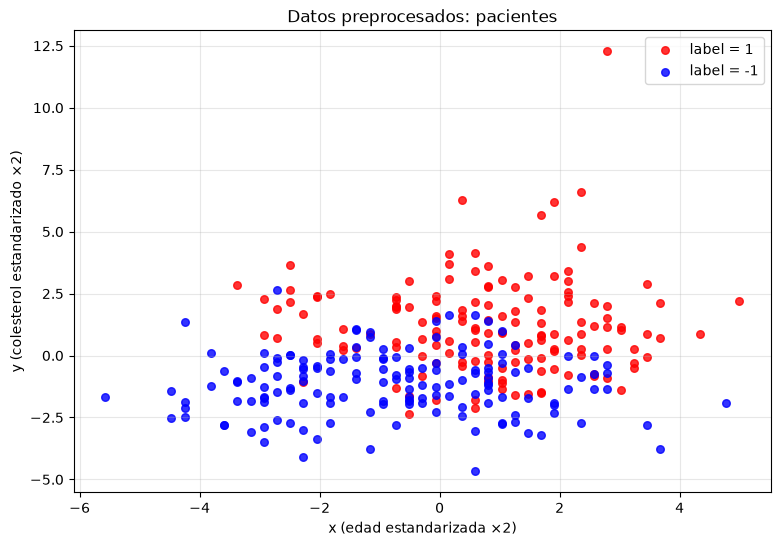

In [10]:
# Visualización de los datos preprocesados (clases +1 / -1)
plt.figure(figsize=(9, 6))
for lab, color in [(1, 'red'), (-1, 'blue')]:
    subset = df[df['label'] == lab]
    plt.scatter(subset['x'], subset['y'], c=color, label=f'label = {lab}', s=30, alpha=0.8)
plt.xlabel('x (edad estandarizada ×2)')
plt.ylabel('y (colesterol estandarizado ×2)')
plt.title('Datos preprocesados: pacientes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paso 2: Generación del Archivo JSON

Se estructura el conjunto preprocesado en el formato requerido por ScienxLab Playground:

```json
[{"x": 100, "y": 2.3, "label": -1}, ...]
```

In [11]:
# Generar el archivo JSON compatible con ScienxLab
registros = df.round(6).to_dict(orient='records')
print('Cantidad de registros:', len(registros))
print('Ejemplo (primeros 3):')
registros[:3]

Cantidad de registros: 298
Ejemplo (primeros 3):


[{'x': 1.914233, 'y': -0.538876, 'label': 1},
 {'x': -3.809995, 'y': 0.118942, 'label': -1},
 {'x': -2.929345, 'y': -1.661037, 'label': -1}]

In [12]:
# Guardar el archivo JSON
with open('pacientes_preprocesado.json', 'w', encoding='utf-8') as f:
    json.dump(registros, f, ensure_ascii=False, indent=2)
print('Archivo pacientes_preprocesado.json generado correctamente.')

Archivo pacientes_preprocesado.json generado correctamente.


### Verificación del archivo JSON generado

In [13]:
# Verificar que el JSON se carga correctamente
with open('pacientes_preprocesado.json', 'r', encoding='utf-8') as f:
    datos_json = json.load(f)
print('Registros cargados:', len(datos_json))
print('Primeros 3 registros:')
datos_json[:3]

Registros cargados: 298
Primeros 3 registros:


[{'x': 1.914233, 'y': -0.538876, 'label': 1},
 {'x': -3.809995, 'y': 0.118942, 'label': -1},
 {'x': -2.929345, 'y': -1.661037, 'label': -1}]

## Paso 3: Análisis de Experimentos en Python (apoyo al informe)

Como apoyo a las pruebas en ScienxLab Playground, se implementa en Python una red neuronal con las mismas condiciones de la plataforma:

- **Problem type:** Classification  
- **Loss function:** Squared error  
- **Activation (ocultas):** ReLU — salida lineal (se clasifica según el signo de la salida, con etiquetas +1/-1)  
- **Regularization:** None  
- **Train:test ratio:** 70% / 30%

### 3.1 División entrenamiento / prueba (70/30)

In [14]:
# Separar características y etiquetas
X = df[['x', 'y']].values
y = df['label'].values

# División 70% entrenamiento - 30% prueba (estratificada para mantener equilibrio de clases)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
print('Entrenamiento:', X_train.shape[0], '| Prueba:', X_test.shape[0])

Entrenamiento: 208 | Prueba: 90


### 3.2 Implementación de la red neuronal (numpy)

In [15]:
def init_red(arquitectura, semilla=42):
    """Inicializa pesos y sesgos para una red con ReLU en ocultas y salida lineal."""
    np.random.seed(semilla)
    W, b = [], []
    for i in range(len(arquitectura) - 1):
        W.append(np.random.randn(arquitectura[i], arquitectura[i+1]) * 0.5)
        b.append(np.zeros(arquitectura[i+1]))
    return W, b

def propagar(X, W, b):
    """Propagación hacia adelante. Devuelve la salida y las activaciones."""
    a = X
    acts = [a]
    for i in range(len(W) - 1):
        a = np.maximum(0, a @ W[i] + b[i])  # ReLU
        acts.append(a)
    out = a @ W[-1] + b[-1]  # salida lineal
    acts.append(out)
    return out, acts

def error_cuadratico(y, out):
    return np.mean((out - np.asarray(y).reshape(-1, 1)) ** 2)

def entrenar(X, y, arquitectura, lr, epocas=2000, semilla=42):
    """Entrena la red con descenso de gradiente (backpropagation) y pérdida cuadrática."""
    y = np.asarray(y).reshape(-1, 1)
    W, b = init_red(arquitectura, semilla)
    perdidas = []
    n = len(y)
    for _ in range(epocas):
        out, acts = propagar(X, W, b)
        perdidas.append(error_cuadratico(y, out))
        # Gradiente de la pérdida cuadrática: dL/dout = 2*(out - y)/n
        grad = 2 * (out - y) / n
        dW, db = [None]*len(W), [None]*len(b)
        for i in range(len(W)-1, -1, -1):
            a_in = acts[i]
            dW[i] = a_in.T @ grad
            db[i] = grad.sum(axis=0)
            if i > 0:
                grad = (grad @ W[i].T) * (acts[i] > 0)  # derivada de ReLU
        for i in range(len(W)):
            W[i] -= lr * dW[i]
            b[i] -= lr * db[i]
    return W, b, perdidas

def precision(y_real, out):
    """Precisión de clasificación (signo de la salida)."""
    pred = np.where(out >= 0, 1, -1).reshape(-1)
    return np.mean(pred == np.asarray(y_real).reshape(-1))

print('Funciones de red neuronal definidas.')

Funciones de red neuronal definidas.


### 3.3 Experimento 1: Tasa de aprendizaje (learning rate)

Se fija la arquitectura `[2, 4, 1]` (2 entradas, 4 neuronas ocultas, 1 salida) y se comparan los learning rates: **0.003, 0.01, 0.03, 0.1 y 0.3**.

In [16]:
learning_rates = [0.003, 0.01, 0.03, 0.1, 0.3]
arquitectura_fija = [2, 4, 1]

resultados_lr = []
curvas_lr = {}
for lr in learning_rates:
    W, b, perd = entrenar(X_train, y_train, arquitectura_fija, lr)
    out_tr, _ = propagar(X_train, W, b)
    out_te, _ = propagar(X_test, W, b)
    resultados_lr.append({
        'learning_rate': lr,
        'perdida_train': round(perd[-1], 6),
        'perdida_test': round(error_cuadratico(y_test, out_te), 6),
        'acc_train': round(precision(y_train, out_tr), 4),
        'acc_test': round(precision(y_test, out_te), 4),
    })
    curvas_lr[lr] = perd

tabla_lr = pd.DataFrame(resultados_lr)
tabla_lr

,learning_rate,perdida_train,perdida_test,acc_train,acc_test
0,0.003,0.576561,0.519180,0.8077,0.8111
1,0.010,0.548633,0.496103,0.8077,0.8222
2,0.030,0.543618,0.491563,0.8173,0.8444
3,0.100,0.526742,0.471935,0.7981,0.8333
4,0.300,0.557432,0.562412,0.8269,0.8222


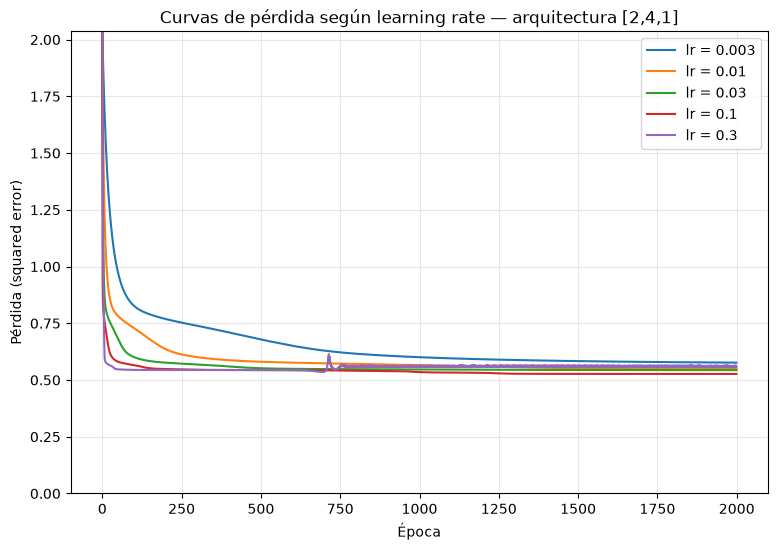

In [17]:
# Curvas de pérdida por learning rate (arquitectura [2,4,1])
plt.figure(figsize=(9, 6))
for lr, perd in curvas_lr.items():
    plt.plot(perd, label=f'lr = {lr}')
plt.xlabel('Época')
plt.ylabel('Pérdida (squared error)')
plt.title('Curvas de pérdida según learning rate — arquitectura [2,4,1]')
plt.legend()
plt.ylim(0, max(curvas_lr[0.003][:20]))
plt.grid(alpha=0.3)
plt.show()

### 3.4 Experimento 2: Arquitectura de la red

Con el mejor learning rate del experimento anterior, se prueban distintas combinaciones de capas ocultas y neuronas por capa.

In [18]:
# Determinar el mejor learning rate por precisión en prueba
mejor_lr = tabla_lr.loc[tabla_lr['acc_test'].idxmax(), 'learning_rate']
print('Mejor learning rate (según acc_test):', mejor_lr)

arquitecturas = [[2, 2, 1], [2, 4, 1], [2, 8, 1], [2, 4, 4, 1], [2, 8, 8, 1], [2, 16, 8, 1]]
resultados_arq = []
curvas_arq = {}
for arq in arquitecturas:
    W, b, perd = entrenar(X_train, y_train, arq, mejor_lr)
    out_tr, _ = propagar(X_train, W, b)
    out_te, _ = propagar(X_test, W, b)
    resultados_arq.append({
        'arquitectura': str(arq),
        'perdida_train': round(perd[-1], 6),
        'perdida_test': round(error_cuadratico(y_test, out_te), 6),
        'acc_train': round(precision(y_train, out_tr), 4),
        'acc_test': round(precision(y_test, out_te), 4),
    })
    curvas_arq[str(arq)] = perd

tabla_arq = pd.DataFrame(resultados_arq)
tabla_arq

Mejor learning rate (según acc_test): 0.03


,arquitectura,perdida_train,perdida_test,acc_train,acc_test
0,"[2, 2, 1]",0.607447,0.529402,0.7981,0.8444
1,"[2, 4, 1]",0.543618,0.491563,0.8173,0.8444
2,"[2, 8, 1]",0.508391,0.530848,0.7933,0.8000
3,"[2, 4, 4, 1]",0.481281,0.494255,0.8221,0.8222
4,"[2, 8, 8, 1]",0.471702,0.526860,0.8269,0.8222
5,"[2, 16, 8, 1]",0.461494,0.501780,0.8173,0.8444


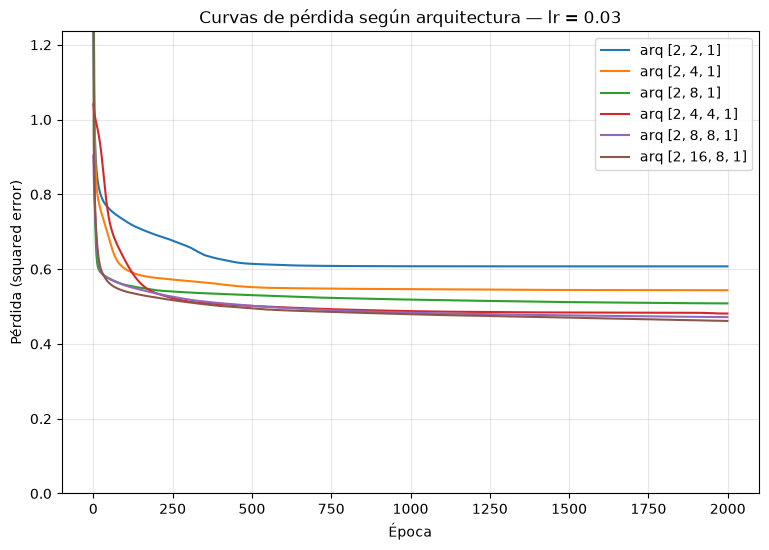

In [19]:
# Curvas de pérdida por arquitectura
plt.figure(figsize=(9, 6))
for nombre, perd in curvas_arq.items():
    plt.plot(perd, label=f'arq {nombre}')
plt.xlabel('Época')
plt.ylabel('Pérdida (squared error)')
plt.title(f'Curvas de pérdida según arquitectura — lr = {mejor_lr}')
plt.legend()
plt.ylim(0, max(curvas_arq[list(curvas_arq.keys())[0]][:20]))
plt.grid(alpha=0.3)
plt.show()

### 3.5 Búsqueda exhaustiva: todas las combinaciones learning rate × arquitectura

Se entrena la red con **todas** las combinaciones (5 learning rates × 6 arquitecturas = 30 modelos) y se construye una tabla completa para elegir el mejor modelo.

In [20]:
# Búsqueda en rejilla: lr x arquitectura (30 combinaciones)
import ast
learning_rates = [0.003, 0.01, 0.03, 0.1, 0.3]
arquitecturas = [[2, 2, 1], [2, 4, 1], [2, 8, 1], [2, 4, 4, 1], [2, 8, 8, 1], [2, 16, 8, 1]]

resultados_grid = []
for lr in learning_rates:
    for arq in arquitecturas:
        W, b, perd = entrenar(X_train, y_train, arq, lr)
        out_tr, _ = propagar(X_train, W, b)
        out_te, _ = propagar(X_test, W, b)
        resultados_grid.append({
            'learning_rate': lr,
            'arquitectura': str(arq),
            'perdida_train': round(perd[-1], 6),
            'perdida_test': round(error_cuadratico(y_test, out_te), 6),
            'acc_train': round(precision(y_train, out_tr), 4),
            'acc_test': round(precision(y_test, out_te), 4),
        })

tabla_grid = pd.DataFrame(resultados_grid)
tabla_grid

C:\Users\user\AppData\Local\Temp\ipykernel_26460\2538948029.py:17: RuntimeWarning: overflow encountered in matmul
  out = a @ W[-1] + b[-1]  # salida lineal
C:\Users\user\AppData\Local\Temp\ipykernel_26460\2538948029.py:38: RuntimeWarning: invalid value encountered in matmul
  dW[i] = a_in.T @ grad
C:\Users\user\AppData\Local\Temp\ipykernel_26460\2538948029.py:41: RuntimeWarning: invalid value encountered in multiply
  grad = (grad @ W[i].T) * (acts[i] > 0)  # derivada de ReLU


,learning_rate,arquitectura,perdida_train,perdida_test,acc_train,acc_test
0,0.003,"[2, 2, 1]",0.691140,0.603060,0.7692,0.8222
1,0.003,"[2, 4, 1]",0.576561,0.519180,0.8077,0.8111
2,0.003,"[2, 8, 1]",0.543230,0.525674,0.8173,0.8222
3,0.003,"[2, 4, 4, 1]",0.535032,0.488189,0.8077,0.8444
4,0.003,"[2, 8, 8, 1]",0.534506,0.506262,0.8173,0.8444
5,0.003,"[2, 16, 8, 1]",0.515939,0.496207,0.8125,0.8222
6,0.010,"[2, 2, 1]",0.609463,0.530561,0.7981,0.8444
7,0.010,"[2, 4, 1]",0.548633,0.496103,0.8077,0.8222
8,0.010,"[2, 8, 1]",0.524870,0.527976,0.8029,0.8222
9,0.010,"[2, 4, 4, 1]",0.495482,0.492431,0.8317,0.8444


### 3.6 Mejor solución

Se selecciona el modelo con mayor precisión en el conjunto de **prueba** y, entre empates, el de menor pérdida en prueba (mejor generalización).

In [21]:
# Mejor modelo según precisión en prueba (desempate: menor pérdida en prueba)
tabla_grid['ranking'] = tabla_grid['acc_test'] * 1000 - tabla_grid['perdida_test']
mejor_fila = tabla_grid.loc[tabla_grid['ranking'].idxmax()]
mejor_lr = mejor_fila['learning_rate']
mejor_arq = ast.literal_eval(mejor_fila['arquitectura'])
print('MEJOR MODELO (búsqueda exhaustiva):')
print(f"  - Arquitectura: {mejor_arq}")
print(f"  - Learning rate: {mejor_lr}")
print(f"  - Pérdida train: {mejor_fila['perdida_train']}")
print(f"  - Pérdida test: {mejor_fila['perdida_test']}")
print(f"  - Acc train: {mejor_fila['acc_train']}")
print(f"  - Acc test: {mejor_fila['acc_test']}")
print('\nTop 5 de la tabla:')
tabla_grid.sort_values('ranking', ascending=False).head(5)

MEJOR MODELO (búsqueda exhaustiva):
  - Arquitectura: [2, 4, 4, 1]
  - Learning rate: 0.003
  - Pérdida train: 0.535032
  - Pérdida test: 0.488189
  - Acc train: 0.8077
  - Acc test: 0.8444

Top 5 de la tabla:


,learning_rate,arquitectura,perdida_train,perdida_test,acc_train,acc_test,ranking
3,0.003,"[2, 4, 4, 1]",0.535032,0.488189,0.8077,0.8444,843.911811
13,0.030,"[2, 4, 1]",0.543618,0.491563,0.8173,0.8444,843.908437
9,0.010,"[2, 4, 4, 1]",0.495482,0.492431,0.8317,0.8444,843.907569
17,0.030,"[2, 16, 8, 1]",0.461494,0.501780,0.8173,0.8444,843.898220
4,0.003,"[2, 8, 8, 1]",0.534506,0.506262,0.8173,0.8444,843.893738


### 3.7 Código de la red: pesos (w) y sesgos (bias) del mejor modelo

Se reentrena el mejor modelo y se extrae la matriz de pesos y los sesgos finales, tal como se copiará desde ScienxLab Playground para el informe.

In [22]:
# Reentrenar el mejor modelo y extraer pesos y sesgos
W_final, b_final, _ = entrenar(X_train, y_train, mejor_arq, mejor_lr)

for i in range(len(W_final)):
    print(f'--- Capa {i} (dimensión {W_final[i].shape}) ---')
    print('Pesos W:', np.round(W_final[i], 6))
    print('Sesgo b:', np.round(b_final[i], 6))

--- Capa 0 (dimensión (2, 4)) ---
Pesos W: [[ 0.354087 -0.174372  0.386553  0.697112]
 [-0.106734 -0.521711  0.855307  0.225004]]
Sesgo b: [ 0.124013  0.003009  0.265068 -0.09277 ]
--- Capa 1 (dimensión (4, 4)) ---
Pesos W: [[-0.248178  0.379255 -0.231709 -0.232865]
 [ 0.494332 -0.984642 -0.862459 -0.281144]
 [-0.655155  0.273716 -0.454012 -0.706152]
 [ 0.606287 -0.017607  0.033764 -0.712374]]
Sesgo b: [0.312472 0.526244 0.       0.      ]
--- Capa 2 (dimensión (4, 1)) ---
Pesos W: [[-0.641226]
 [ 0.665088]
 [-0.575497]
 [ 0.187849]]
Sesgo b: [-0.174157]


### 3.8 Frontera de decisión del mejor modelo

Se grafica la frontera de decisión (regiones donde la red clasifica +1 y -1) junto con los datos, equivalente a la visualización de ScienxLab Playground.

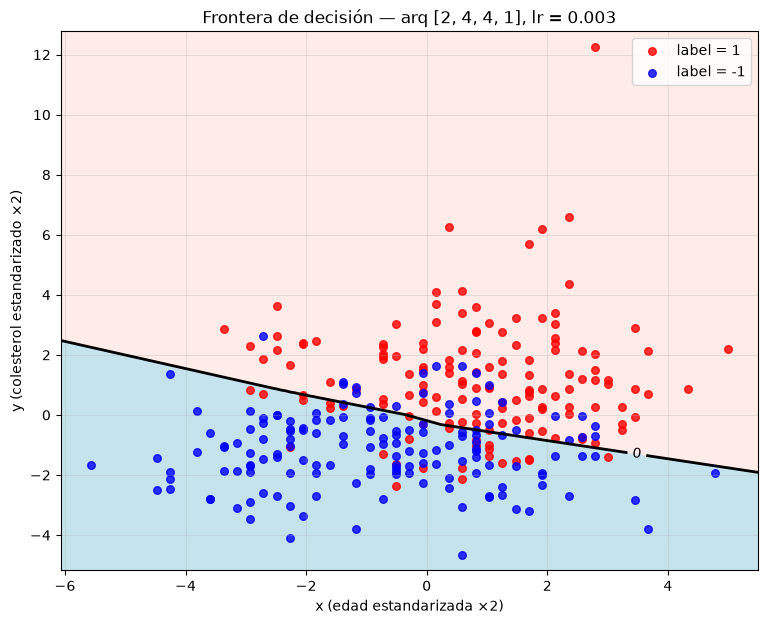

In [23]:
# Graficar frontera de decisión
x_min, x_max = df['x'].min() - 0.5, df['x'].max() + 0.5
y_min, y_max = df['y'].min() - 0.5, df['y'].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
out_grid, _ = propagar(grid, W_final, b_final)
zz = out_grid.reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, zz, levels=[-np.inf, 0, np.inf], colors=('lightblue', 'mistyrose'), alpha=0.7)
cont = plt.contour(xx, yy, zz, levels=[0], colors='black', linewidths=2)
plt.clabel(cont, inline=True, fontsize=10)
for lab, color in [(1, 'red'), (-1, 'blue')]:
    subset = df[df['label'] == lab]
    plt.scatter(subset['x'], subset['y'], c=color, label=f'label = {lab}', s=30, alpha=0.8)
plt.xlabel('x (edad estandarizada ×2)')
plt.ylabel('y (colesterol estandarizado ×2)')
plt.title(f'Frontera de decisión — arq {mejor_arq}, lr = {mejor_lr}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.9 Guardar resultados de los experimentos

Se exportan las tablas de resultados para incluirlas en el informe.

In [24]:
tabla_lr.to_csv('resultados_learning_rate.csv', index=False)
tabla_arq.to_csv('resultados_arquitectura.csv', index=False)
tabla_grid.to_csv('resultados_busqueda_exhaustiva.csv', index=False)
print('Tablas guardadas: resultados_learning_rate.csv, resultados_arquitectura.csv y resultados_busqueda_exhaustiva.csv')

Tablas guardadas: resultados_learning_rate.csv, resultados_arquitectura.csv y resultados_busqueda_exhaustiva.csv


## Guía: Entrenamiento en ScienxLab Playground

1. Ingresar a 👉 **https://playground.scienxlab.org**.
2. Cargar el archivo `pacientes_preprocesado.json` generado en el Paso 2.
3. Configurar los hiperparámetros fijos:

| Hiperparámetro | Configuración |
|----------------|---------------|
| Problem type | Classification |
| Loss function | Squared error |
| Activation | ReLU |
| Regularization | None |
| Train:test ratio | 70% |

4. **Experimento 1 (Learning rate):** mantener una arquitectura fija y comparar `0.003`, `0.01`, `0.03`, `0.1` y `0.3`.
5. **Experimento 2 (Arquitectura):** con el mejor learning rate, probar distintas combinaciones de capas ocultas y neuronas por capa (ej. 1 capa con 4 u 8 neuronas; 2 capas con 4-4, 8-8, 16-8; 3 capas con 4-4-4, etc.).
6. Tomar capturas de pantalla de la **red entrenada final** y de la **frontera de decisión**.
7. Copiar el **código de la red (pesos w y sesgos bias)** que genera la plataforma para la mejor solución.

---

## Estructura del informe final

1. **Análisis de experimentos:** resumen de las pruebas variando arquitectura y learning rate (usar las tablas y curvas de este cuaderno como apoyo).
2. **Mejor solución:** configuración ganadora y justificación teórica — comportamiento de la función de pérdida (squared error), rendimiento en entrenamiento vs. prueba (evitar sobreajuste y subajuste), convergencia según learning rate (valores muy pequeños convergen lento; valores muy grandes oscilan o divergen).
3. **Evidencia visual:** capturas de pantalla de la red entrenada final y de la frontera de decisión en ScienxLab.
4. **Código de la red:** matriz final de pesos ($w$) y sesgos (bias) de la mejor solución.